# **Introduction**
This project focuses on customer segmentation using marketing campaign data to identify groups of customers with similar demographic and purchasing characteristics.
We will apply data preprocessing, feature engineering, dimensionality reduction (PCA), and clustering techniques to discover meaningful customer segments.

### Dataset Introduction

This dataset contains detailed customer profile, transaction, and marketing response data collected from 2,240 retail customers. It tracks key demographic traits, spending across six product categories, purchasing channel preferences, and responses to multiple promotional campaigns over a two-year period. The primary goal of this dataset is to perform customer personality analysis, segmentation, and target response modeling to optimize marketing strategies.

---
### Column Descriptions

* **`ID`**: Unique identifier assigned to each individual customer.
* **`Year_Birth`**: Birth year of the customer, used to calculate customer age.
* **`Education`**: Highest level of formal education completed by the customer (e.g., Graduation, PhD, Master).
* **`Marital_Status`**: Living or marital arrangement of the customer (e.g., Single, Married, Together, Divorced).
* **`Income`**: Yearly household income earned by the customer in US dollars.
* **`Kidhome`**: Number of small children currently living in the customer's household.
* **`Teenhome`**: Number of teenagers currently living in the customer's household.
* **`Dt_Customer`**: Date when the customer was first enrolled with the company.
* **`Recency`**: Number of days elapsed since the customer's last purchase.
* **`MntWines`**: Total dollar amount spent on wine products over the last two years.
* **`MntFruits`**: Total dollar amount spent on fruit products over the last two years.
* **`MntMeatProducts`**: Total dollar amount spent on meat products over the last two years.
* **`MntFishProducts`**: Total dollar amount spent on fish products over the last two years.
* **`MntSweetProducts`**: Total dollar amount spent on sweet/dessert products over the last two years.
* **`MntGoldProds`**: Total dollar amount spent on premium or gold products over the last two years.
* **`NumDealsPurchases`**: Number of purchases made by the customer using a discount or deal offer.
* **`NumWebPurchases`**: Number of purchases completed through the company's website.
* **`NumCatalogPurchases`**: Number of purchases completed using a printed catalog.
* **`NumStorePurchases`**: Number of purchases completed directly inside physical retail stores.
* **`NumWebVisitsMonth`**: Number of visits made by the customer to the company website within the last month.
* **`AcceptedCmp3`**: Binary indicator showing whether the customer accepted the offer in the 3rd marketing campaign (1 = Yes, 0 = No).
* **`AcceptedCmp4`**: Binary indicator showing whether the customer accepted the offer in the 4th marketing campaign (1 = Yes, 0 = No).
* **`AcceptedCmp5`**: Binary indicator showing whether the customer accepted the offer in the 5th marketing campaign (1 = Yes, 0 = No).
* **`AcceptedCmp1`**: Binary indicator showing whether the customer accepted the offer in the 1st marketing campaign (1 = Yes, 0 = No).
* **`AcceptedCmp2`**: Binary indicator showing whether the customer accepted the offer in the 2nd marketing campaign (1 = Yes, 0 = No).
* **`Complain`**: Binary indicator showing whether the customer lodged a complaint in the last two years (1 = Yes, 0 = No).
* **`Z_CostContact`**: Constant benchmark cost value associated with contacting a customer for marketing.
* **`Z_Revenue`**: Constant benchmark revenue generated per successful campaign conversion.
* **`Response`**: Binary indicator showing whether the customer accepted the offer in the most recent marketing campaign (1 = Yes, 0 = No).

In [136]:
#

In [137]:
# Importing dependencies 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

## Reading the dataset

In [138]:
# Loading the dataset
df = pd.read_csv("D:/Python programming/Projects/Custumer Segmentation/marketing_campaign.csv", sep = "\t")

In [139]:
df.iloc[:,:15].sample(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
1757,3524,1971,Master,Single,39763.0,1,0,04-08-2013,9,80,1,60,4,6,16
1399,10490,1969,PhD,Married,51039.0,1,1,10-12-2012,11,100,64,79,65,0,109
811,5585,1972,Graduation,Single,21359.0,1,0,20-04-2013,1,12,2,17,6,1,10
1853,9595,1961,Graduation,Together,64260.0,0,0,11-01-2013,1,539,169,816,20,0,30
1007,241,1952,Graduation,Together,83844.0,0,0,12-05-2013,57,901,31,345,75,31,191


In [140]:
df.iloc[:,15:].sample(5)

,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
643,2,5,4,4,5,1,0,0,0,0,0,3,11,0
86,5,3,1,4,7,0,1,0,0,0,0,3,11,0
2079,2,4,1,4,6,0,0,0,0,0,0,3,11,0
1502,6,7,1,6,8,0,0,0,0,0,0,3,11,1
925,3,6,1,6,8,0,0,0,0,0,0,3,11,0


In [141]:
df.shape

(2240, 29)

In [142]:
print("Column Names: ")
print("")
print(df.columns.tolist()[:10])
print(df.columns.tolist()[10:18])
print(df.columns.tolist()[18:25])
print(df.columns.tolist()[25:])

Column Names: 

['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines']
['MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases']
['NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2']
['Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


## EDA & Data Cleaning

In [143]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [144]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [145]:
df.dropna(inplace=True)

In [146]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2216.0,5588.353339,3249.376275,0.0,2814.75,5458.5,8421.75,11191.0
Year_Birth,2216.0,1968.820397,11.985554,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2216.0,0.441787,0.536896,0.0,0.00,0.0,1.00,2.0
Teenhome,2216.0,0.505415,0.544181,0.0,0.00,0.0,1.00,2.0
Recency,2216.0,49.012635,28.948352,0.0,24.00,49.0,74.00,99.0
MntWines,2216.0,305.091606,337.327920,0.0,24.00,174.5,505.00,1493.0
MntFruits,2216.0,26.356047,39.793917,0.0,2.00,8.0,33.00,199.0
MntMeatProducts,2216.0,166.995939,224.283273,0.0,16.00,68.0,232.25,1725.0
MntFishProducts,2216.0,37.637635,54.752082,0.0,3.00,12.0,50.00,259.0


In [147]:
df = df.drop(columns = ['ID', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue'])

In [148]:
df.shape

(2216, 25)

In [149]:
categorical_cols = ['Education','Marital_Status','AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Complain','Response', 'Kidhome','Teenhome']

In [150]:
numerical_cols = ['Year_Birth','Income','Recency','MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts',
                  'MntGoldProds','NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumStorePurchases','NumWebVisitsMonth']

### Categorical columns

In [151]:
# Value counts
for col in categorical_cols:
    display(df[col].value_counts())

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

AcceptedCmp1
0    2074
1     142
Name: count, dtype: int64

AcceptedCmp2
0    2186
1      30
Name: count, dtype: int64

AcceptedCmp3
0    2053
1     163
Name: count, dtype: int64

...

AcceptedCmp5
0    2054
1     162
Name: count, dtype: int64

Complain
0    2195
1      21
Name: count, dtype: int64

Response
0    1883
1     333
Name: count, dtype: int64

Kidhome
0    1283
1     887
2      46
Name: count, dtype: int64

Teenhome
0    1147
1    1018
2      51
Name: count, dtype: int64

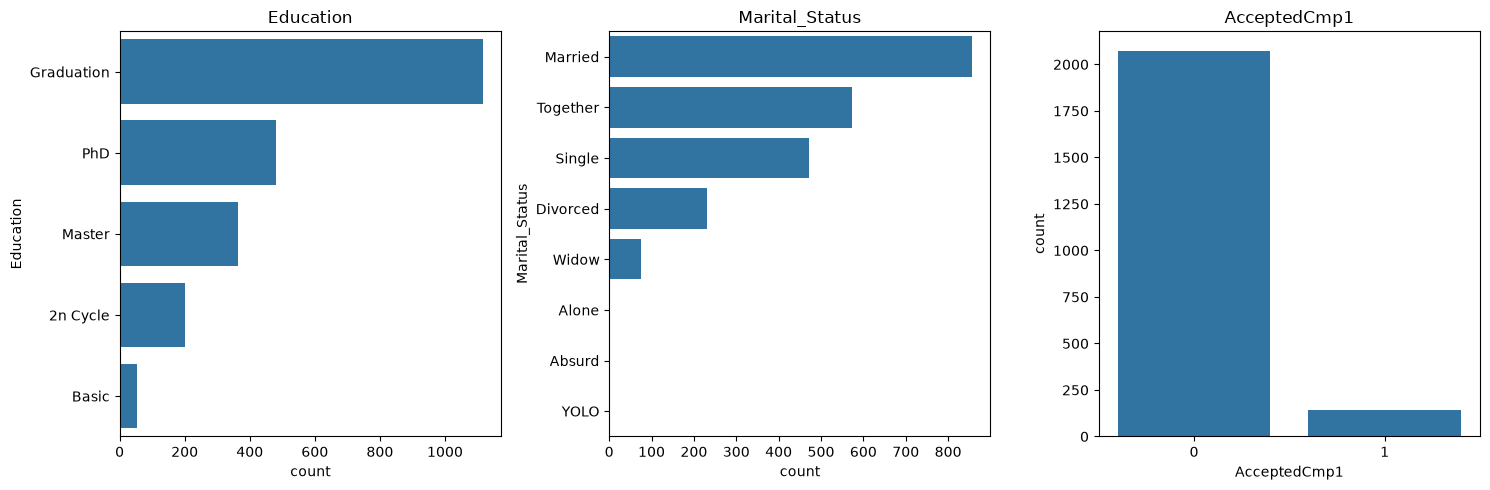

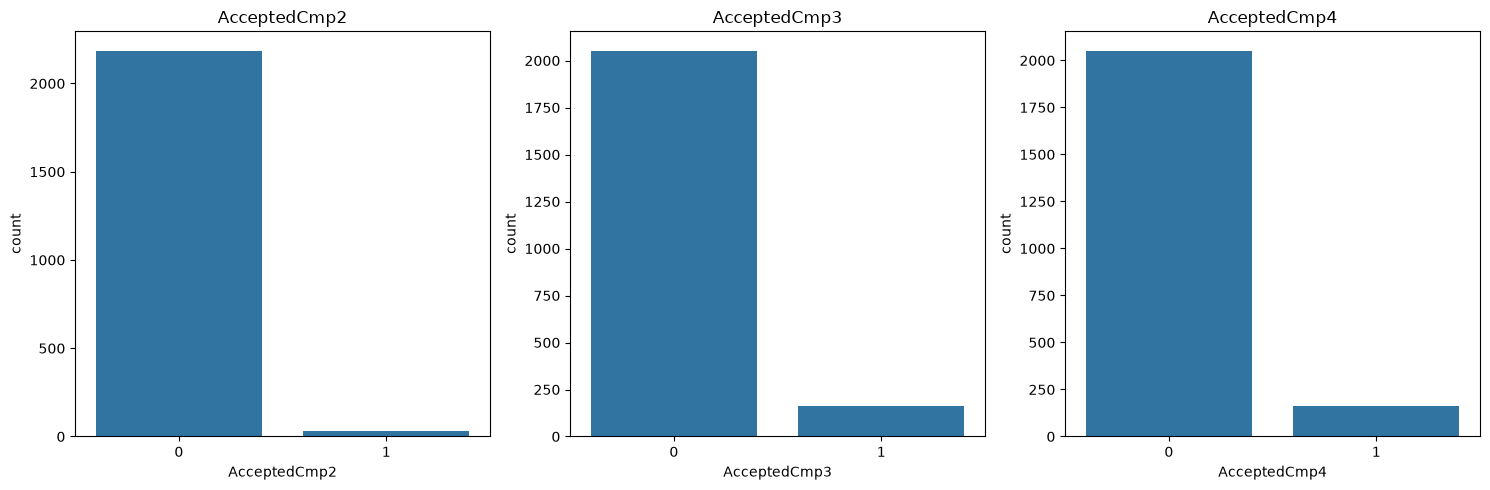

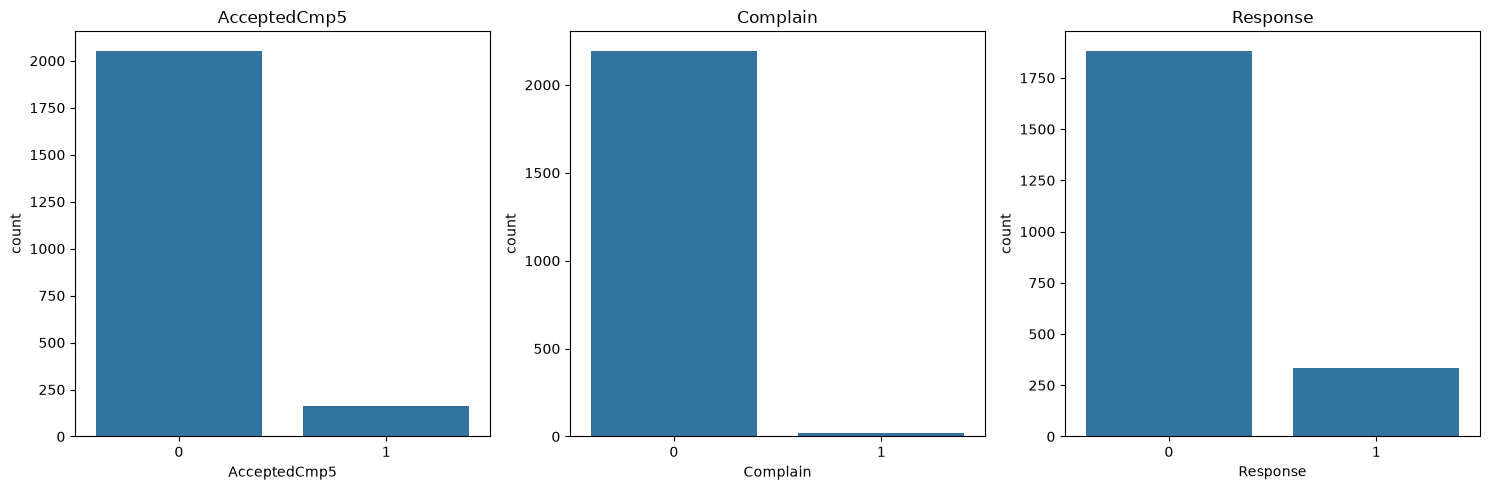

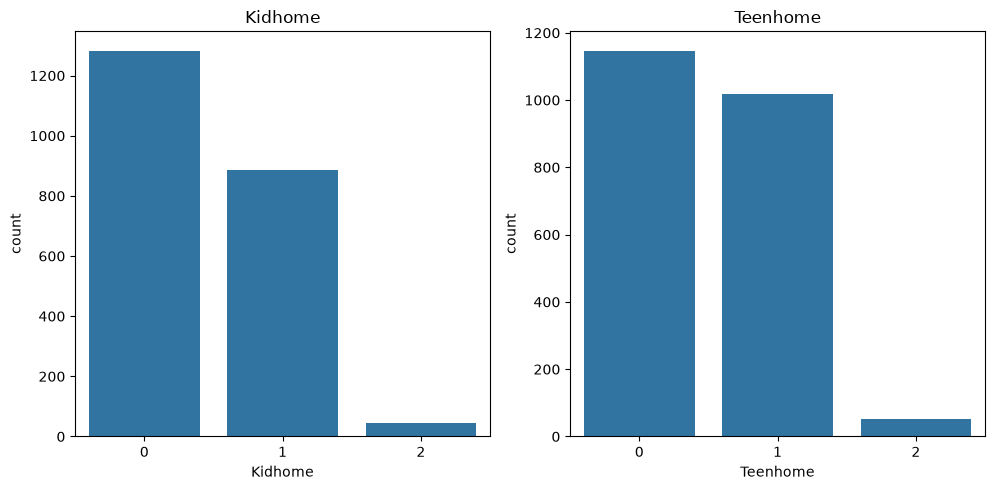

In [152]:
# Count plots
plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, (i % 3) + 1)
    if df[col].nunique() > 4:
        sns.countplot(data=df,y=col,order=df[col].value_counts().index)
    else:
        sns.countplot(data=df,x=col,order=df[col].value_counts().index)
    plt.title(col)
    plt.tight_layout()

    if (i + 1) % 3 == 0:
        plt.show()
        plt.figure(figsize=(15, 5))

### Categorical EDA — Key Findings
- Graduation is the dominant education level (50.3%), followed by PhD (21.7%) and Master (16.5%).
- Married (38.6%), Together (25.9%), and Single (21.4%) customers form the majority of the dataset.
- Previous campaign acceptance is very low, ranging from 1.3% (Campaign 2) to 7.5% (Campaign 4).
- Campaign 2 has the lowest acceptance rate (1.34%), while Campaign 4 has the highest (7.46%).
- Customer complaints are extremely rare, with only 0.94% of customers reporting a complaint.
- The latest campaign (Response) has a 14.91% acceptance rate, indicating a strongly imbalanced response variable.

### Numerical Features

In [153]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Year_Birth,2216.0,1968.820397,11.985554,1893.0,1959.0,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.0,51381.5,68522.00,666666.0
Recency,2216.0,49.012635,28.948352,0.0,24.0,49.0,74.00,99.0
MntWines,2216.0,305.091606,337.327920,0.0,24.0,174.5,505.00,1493.0
MntFruits,2216.0,26.356047,39.793917,0.0,2.0,8.0,33.00,199.0
MntMeatProducts,2216.0,166.995939,224.283273,0.0,16.0,68.0,232.25,1725.0
MntFishProducts,2216.0,37.637635,54.752082,0.0,3.0,12.0,50.00,259.0
MntSweetProducts,2216.0,27.028881,41.072046,0.0,1.0,8.0,33.00,262.0
MntGoldProds,2216.0,43.965253,51.815414,0.0,9.0,24.5,56.00,321.0
NumDealsPurchases,2216.0,2.323556,1.923716,0.0,1.0,2.0,3.00,15.0


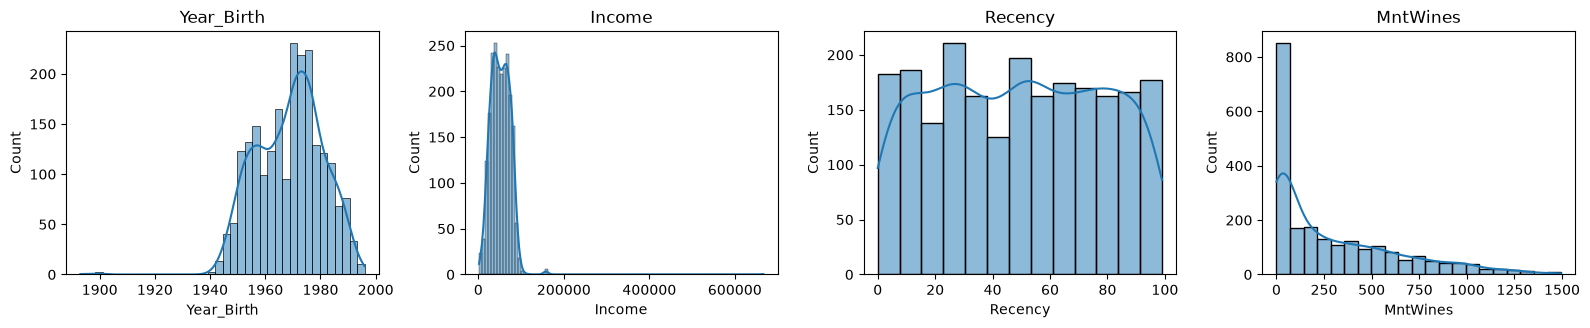

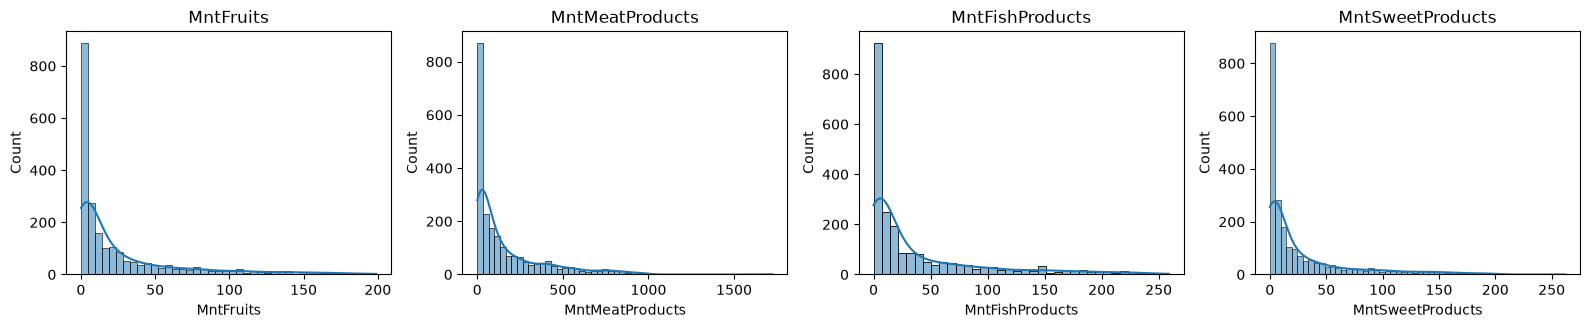

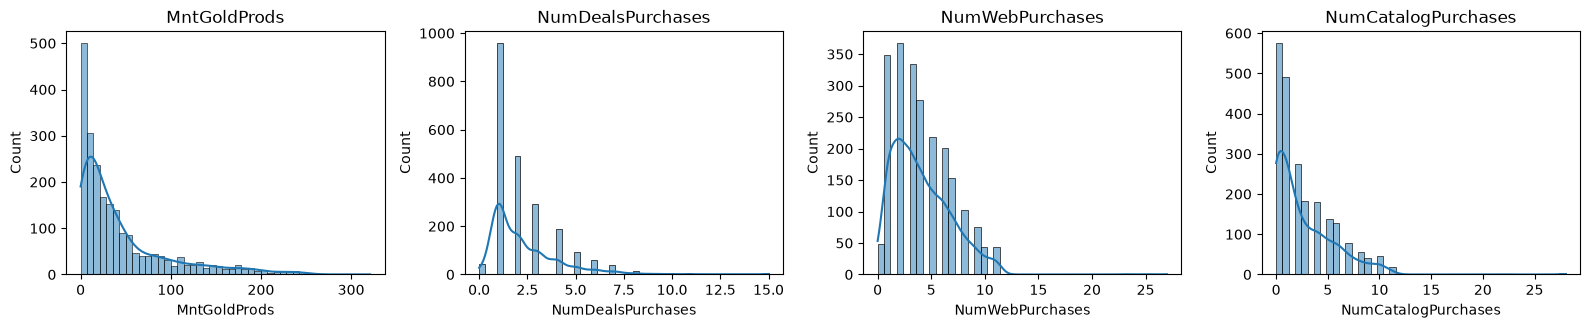

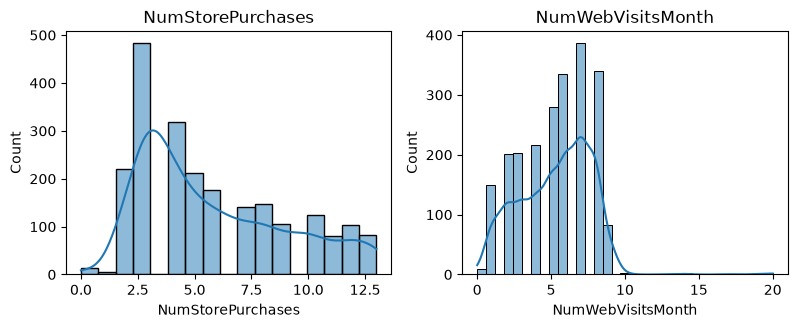

In [154]:
for i, col in enumerate(numerical_cols):
    if i % 4 == 0:
        plt.figure(figsize=(16, 12))
    plt.subplot(4, 4, (i % 4) + 1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.tight_layout()

    if i % 4 == 3 or i == len(numerical_cols) - 1:
        plt.show()

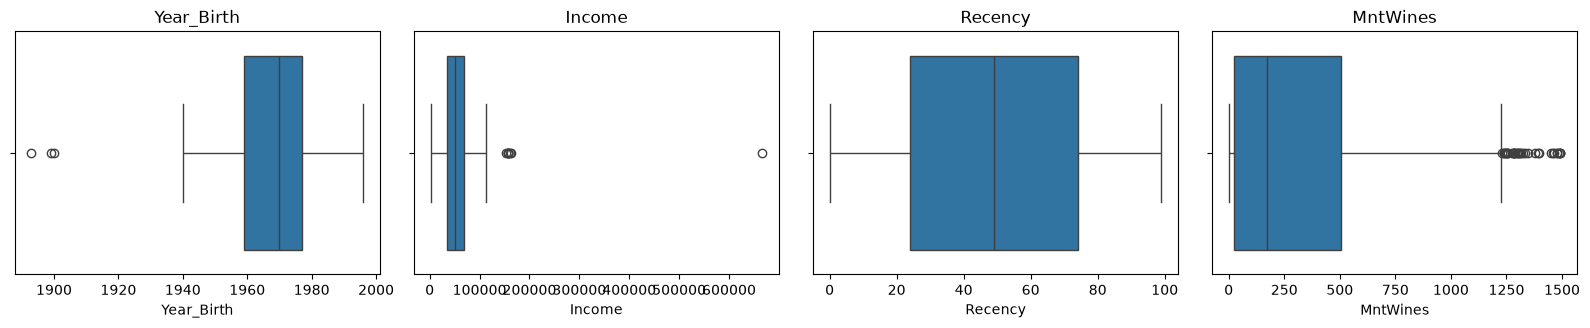

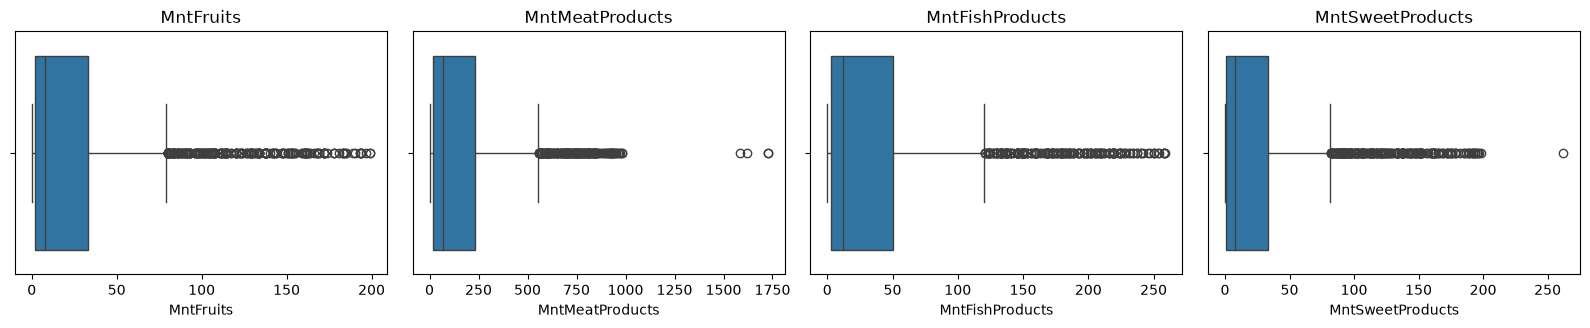

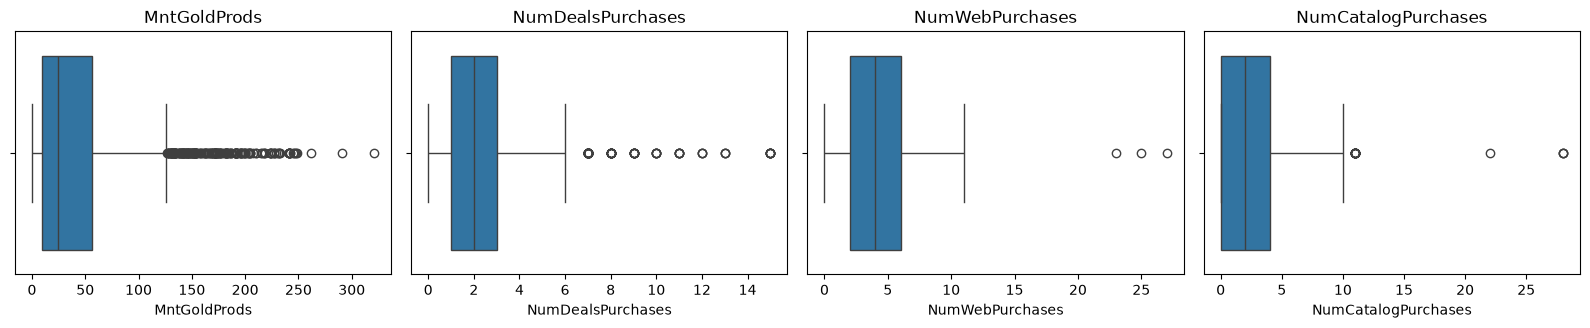

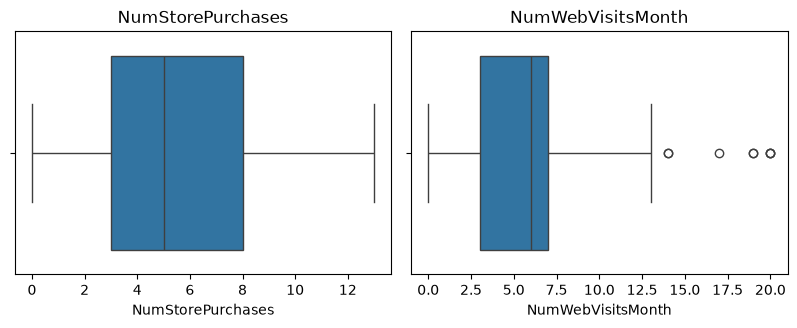

In [155]:
for i, col in enumerate(numerical_cols):
    if i % 4 == 0:
        plt.figure(figsize=(16, 12))
    plt.subplot(4, 4, (i % 4) + 1)
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.tight_layout()

    if i % 4 == 3 or i == len(numerical_cols) - 1:
        plt.show()

In [156]:
skewness = df[numerical_cols].skew().sort_values(ascending=False)
skewness_df = pd.DataFrame({'Feature': skewness.index,'Skewness': skewness.values}).reset_index(drop=True)
skewness_df

,Feature,Skewness
0,Income,6.763487
1,NumDealsPurchases,2.415272
2,MntSweetProducts,2.103328
3,MntFruits,2.101658
4,MntMeatProducts,2.025577
5,MntFishProducts,1.916369
6,NumCatalogPurchases,1.881075
7,MntGoldProds,1.839231
8,NumWebPurchases,1.197037
9,MntWines,1.170720


### Numerical EDA — Key Findings

- `Year_Birth` is concentrated mainly between the 1950s–1980s, with a few unusually low birth-year observations that may require investigation.
- `Income` is highly right-skewed, with a few extreme high-income observations, including a maximum of approximately **$666K**.
- `Recency` is fairly evenly distributed across its range (0–99 days), showing no strong skewness.
- All six product-spending variables are **strongly right-skewed**, with many customers having low/zero spending and a small number of high spenders.
- `MntMeatProducts` and `MntWines` show the highest spending ranges, reaching approximately **$1,725** and **$1,493**, respectively.
- Purchase-count variables (`NumDealsPurchases`, `NumWebPurchases`, `NumCatalogPurchases`) are right-skewed, with most customers making relatively few purchases.
- `NumStorePurchases` has a comparatively broader distribution, with a median of **5 purchases** and a maximum of **13**.
- `NumWebVisitsMonth` is concentrated around **3–8 visits per month**, with a few higher-visit observations.
- Boxplots confirm the presence of **substantial outliers**, particularly in income and product-spending variables.
- The strong skewness and outliers suggest that **feature transformation and scaling should be carefully considered before PCA and clustering**.

### Correlation heatmap

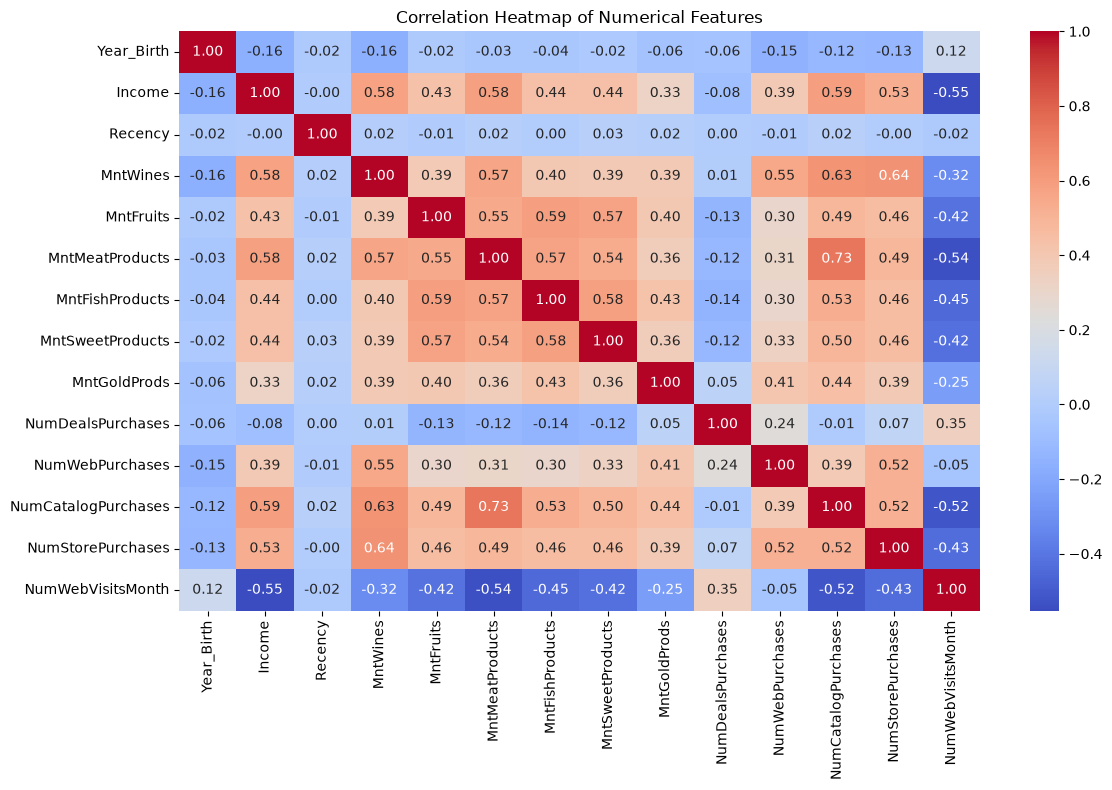

In [157]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_cols].corr(),annot=True,fmt='.2f',cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()